In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv('banglore.csv')

In [4]:
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [5]:
df.isnull().sum()

area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
dtype: int64

In [6]:
df.shape

(13320, 9)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


In [8]:
df.describe()

,bath,balcony,price
count,13247.000000,12711.000000,13320.000000
mean,2.692610,1.584376,112.565627
std,1.341458,0.817263,148.971674
min,1.000000,0.000000,8.000000
25%,2.000000,1.000000,50.000000
50%,2.000000,2.000000,72.000000
75%,3.000000,2.000000,120.000000
max,40.000000,3.000000,3600.000000


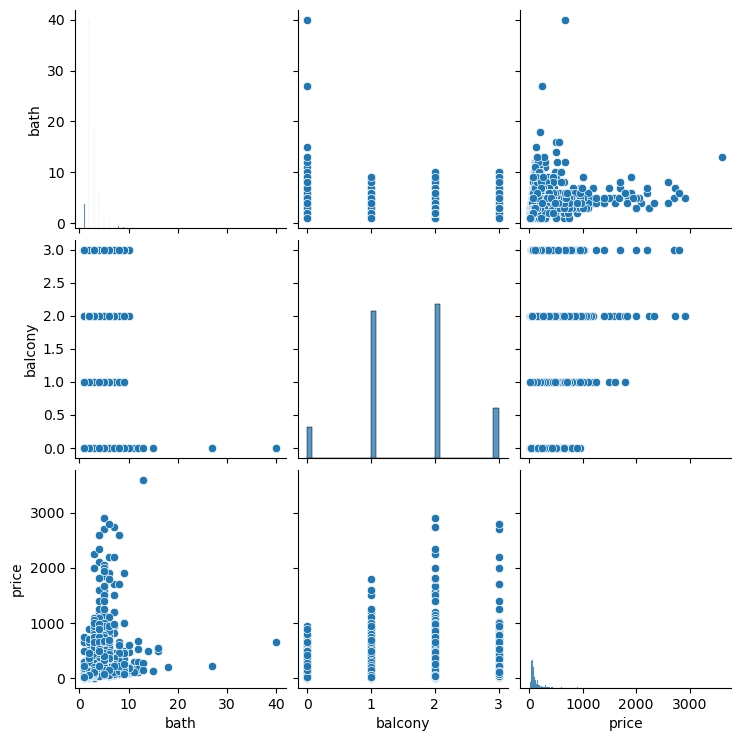

In [9]:
sns.pairplot(df)

In [10]:
#value count of each feature
def value_count(df):
    for i in df.columns:
        print(df[i].value_counts())
        print("-----------------------------------------")

<Axes: >

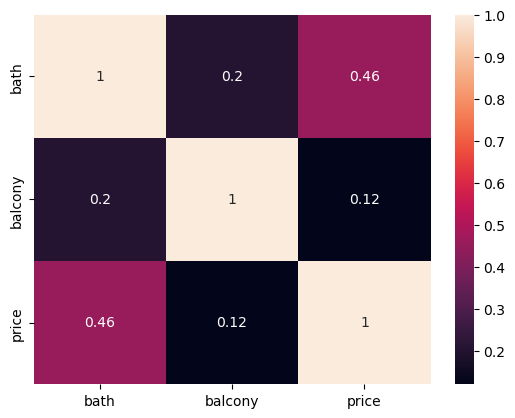

In [11]:
num_vars=['bath','balcony','price']
sns.heatmap(df[num_vars].corr(),annot=True)

In [12]:
df.isnull().sum()

area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
dtype: int64

In [13]:
df.isnull().mean()*100

area_type        0.000000
availability     0.000000
location         0.007508
size             0.120120
society         41.306306
total_sqft       0.000000
bath             0.548048
balcony          4.572072
price            0.000000
dtype: float64

<Axes: >

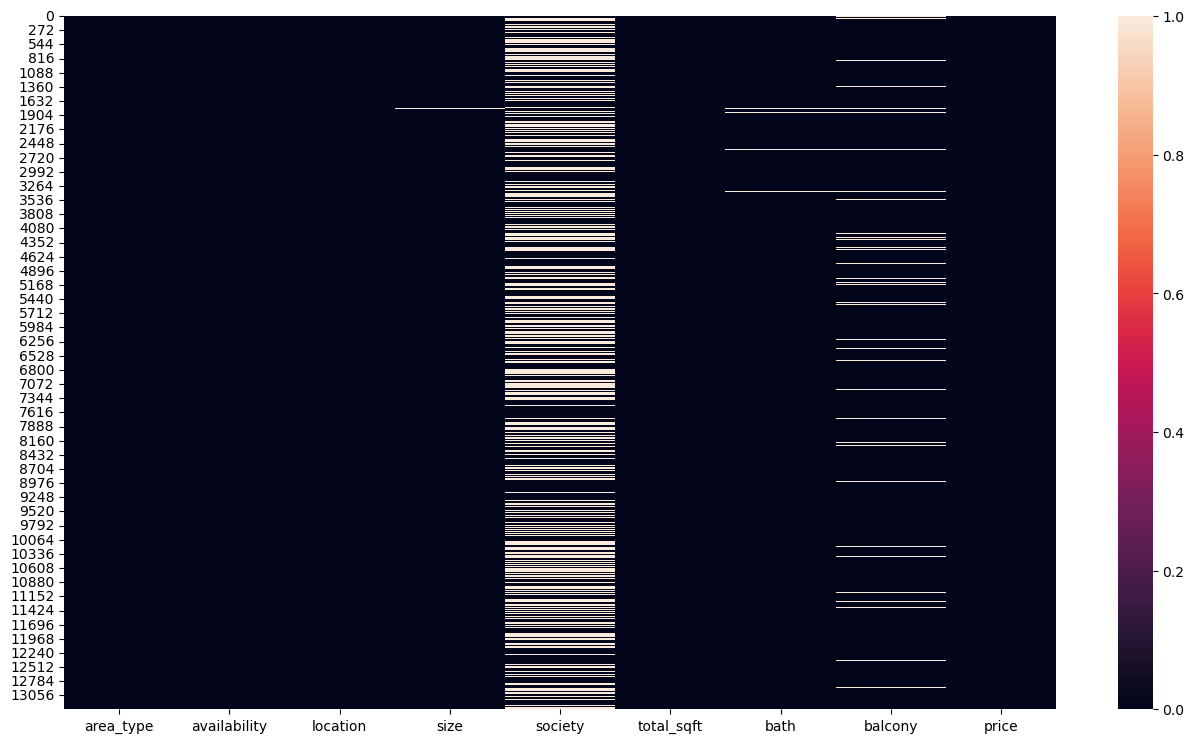

In [14]:
plt.figure(figsize=(16,9))
sns.heatmap(df.isnull())

In [15]:
df2=df.drop('society',axis='columns')
df2.shape

(13320, 8)

In [16]:
df2['balcony']=df2['balcony'].fillna(df2['balcony'].mean())
df2.isnull().sum()

area_type        0
availability     0
location         1
size            16
total_sqft       0
bath            73
balcony          0
price            0
dtype: int64

In [17]:
df3=df2.dropna()
df3.shape

(13246, 8)

In [18]:
df3.isnull().sum()

area_type       0
availability    0
location        0
size            0
total_sqft      0
bath            0
balcony         0
price           0
dtype: int64

In [19]:
df3.head()

,area_type,availability,location,size,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,1200,2.0,1.0,51.00


In [20]:
pd.set_option("display.max_columns",None)
pd.set_option("display.max_rows",None)

In [21]:
df3['total_sqft'].value_counts().sample(5)

total_sqft
871      1
1245    25
2489     1
510      5
5924     1
Name: count, dtype: int64

In [22]:
def convert_sqft(x):
    if '-' in str(x):
        tokens = x.split('-')
        return (float(tokens[0]) + float(tokens[1])) / 2
    try:
        return float(x)
    except:
        return None

df3['total_sqft'] = df3['total_sqft'].apply(convert_sqft)


C:\Users\karti\AppData\Local\Temp\ipykernel_5884\3705759110.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3['total_sqft'] = df3['total_sqft'].apply(convert_sqft)


In [23]:
df3['total_sqft'].value_counts().sample(5)

total_sqft
1914.0    2
1519.0    3
769.0     1
1466.0    4
1386.0    4
Name: count, dtype: int64

In [24]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13246 entries, 0 to 13319
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13246 non-null  object 
 1   availability  13246 non-null  object 
 2   location      13246 non-null  object 
 3   size          13246 non-null  object 
 4   total_sqft    13200 non-null  float64
 5   bath          13246 non-null  float64
 6   balcony       13246 non-null  float64
 7   price         13246 non-null  float64
dtypes: float64(4), object(4)
memory usage: 931.4+ KB


In [25]:
df3.head()

,area_type,availability,location,size,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,1056.0,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,2600.0,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,1440.0,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,1521.0,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,1200.0,2.0,1.0,51.00


In [26]:
df3['size'].unique()


array(['2 BHK', '4 Bedroom', '3 BHK', '4 BHK', '6 Bedroom', '3 Bedroom',
       '1 BHK', '1 RK', '1 Bedroom', '8 Bedroom', '2 Bedroom',
       '7 Bedroom', '5 BHK', '7 BHK', '6 BHK', '5 Bedroom', '11 BHK',
       '9 BHK', '9 Bedroom', '27 BHK', '10 Bedroom', '11 Bedroom',
       '10 BHK', '19 BHK', '16 BHK', '43 Bedroom', '14 BHK', '8 BHK',
       '12 Bedroom', '13 BHK', '18 Bedroom'], dtype=object)

In [27]:
df3['bhk'] = df3['size'].str.split().str[0].astype(float)

C:\Users\karti\AppData\Local\Temp\ipykernel_5884\1277595738.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3['bhk'] = df3['size'].str.split().str[0].astype(float)


In [28]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13246 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13246 non-null  object 
 1   availability  13246 non-null  object 
 2   location      13246 non-null  object 
 3   size          13246 non-null  object 
 4   total_sqft    13200 non-null  float64
 5   bath          13246 non-null  float64
 6   balcony       13246 non-null  float64
 7   price         13246 non-null  float64
 8   bhk           13246 non-null  float64
dtypes: float64(5), object(4)
memory usage: 1.0+ MB


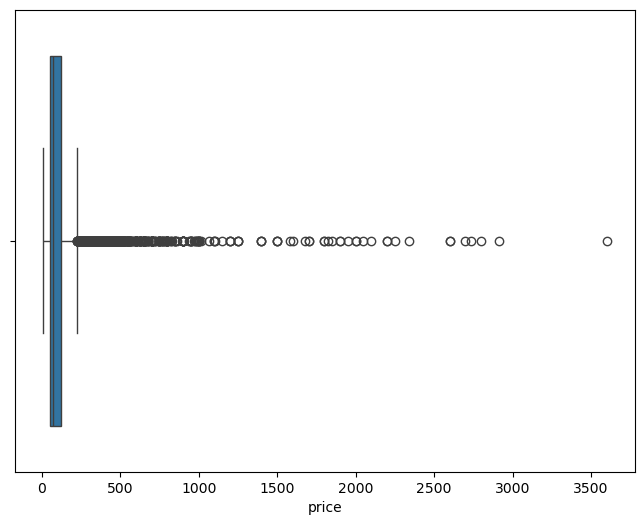

In [29]:
plt.figure(figsize=(8,6))
sns.boxplot(x=df3['price'])
plt.show()

In [30]:
df3.shape

(13246, 9)

In [31]:
Q1 = df3['price'].quantile(0.25)
Q3 = df3['price'].quantile(0.75)
IQR = Q3 - Q1


In [32]:
df3 = df3[
    (df3['price'] >= Q1 - 1.5*IQR) &
    (df3['price'] <= Q3 + 1.5*IQR)
]

In [33]:
df3.shape

(11987, 9)

In [34]:
Q1 = df3['bhk'].quantile(0.25)
Q3 = df3['bhk'].quantile(0.75)

IQR = Q3 - Q1
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print("Lower:", lower_limit)
print("Upper:", upper_limit)


Lower: 0.5
Upper: 4.5


In [35]:
df3 = df3[
    (df3['bhk'] >= lower_limit) &
    (df3['bhk'] <= upper_limit)
]


In [36]:
df3.shape

(11428, 9)

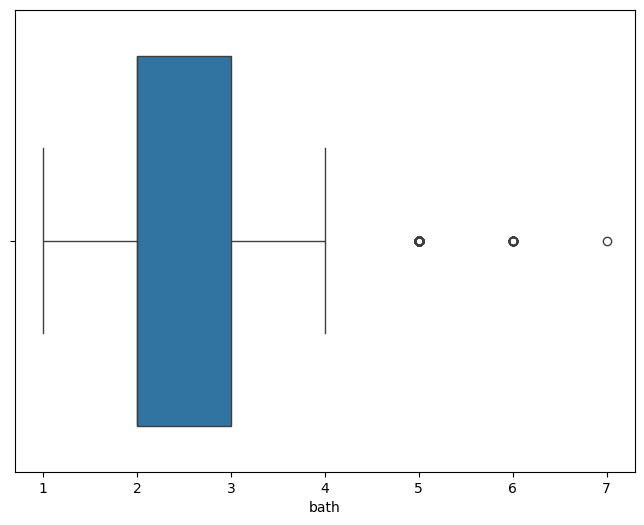

In [37]:
plt.figure(figsize=(8,6))
sns.boxplot(x=df3['bath'])
plt.show()

In [38]:
Q1 = df3['bath'].quantile(0.25)
Q3 = df3['bath'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df3 = df3[(df3['bath'] >= lower) & (df3['bath'] <= upper)]


In [39]:
df3.head()

,area_type,availability,location,size,total_sqft,bath,balcony,price,bhk
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,1056.0,2.0,1.0,39.07,2.0
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,1440.0,2.0,3.0,62.00,3.0
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,1521.0,3.0,1.0,95.00,3.0
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,1200.0,2.0,1.0,51.00,2.0
5,Super built-up Area,Ready To Move,Whitefield,2 BHK,1170.0,2.0,1.0,38.00,2.0


In [40]:
location_counts = df3['location'].value_counts()

df3['location'] = df3['location'].apply(
    lambda x: 'other' if location_counts[x] < 10 else x
)


In [41]:
df3 = pd.get_dummies(df3, columns=['location'], drop_first=True)


In [48]:
df3 = df3.drop(['availability', 'area_type', 'size'], axis=1, errors='ignore')


In [57]:
df3.isnull().sum()

total_sqft                              0
bath                                    0
balcony                                 0
price                                   0
bhk                                     0
location_1st Phase JP Nagar             0
location_2nd Phase Judicial Layout      0
location_5th Phase JP Nagar             0
location_6th Phase JP Nagar             0
location_7th Phase JP Nagar             0
location_8th Phase JP Nagar             0
location_9th Phase JP Nagar             0
location_AECS Layout                    0
location_Abbigere                       0
location_Akshaya Nagar                  0
location_Ambalipura                     0
location_Ambedkar Nagar                 0
location_Amruthahalli                   0
location_Anandapura                     0
location_Ananth Nagar                   0
location_Anekal                         0
location_Anjanapura                     0
location_Ardendale                      0
location_Arekere                  

In [54]:
df3 = df3.dropna(subset=['total_sqft'])

In [64]:
X = df3.drop('price', axis=1)
y = df3['price']


In [65]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [66]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

model.score(X_test, y_test)

0.5133137695855012

In [67]:
import pickle

pickle.dump(model, open('bangalore_price_model.pkl', 'wb'))


In [68]:
import json

columns = {
    'data_columns': list(X.columns)
}

with open("columns.json", "w") as f:
    json.dump(columns, f)


In [69]:

import os
os.getcwd()


'c:\\Users\\karti\\OneDrive\\Desktop\\ml_project'